In [1]:
data_dir = '/scratch/mjehangir/aysa_severus_results/'

In [2]:
setwd(data_dir)

In [3]:
# Load necessary libraries
library(openxlsx)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)
library(scales)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package

In [4]:
# Load the data from your txt file
file_path <- "./severus_reshaped.tsv"
data <- read.table(file_path, header = TRUE, sep = "\t")
head(data)

,chr,start,end,size,type,sample
,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,chr1,3010201,3010201,0,INS,2436A
2,chr1,8976617,8976617,0,INS,2436A
3,chr1,15789450,15789450,0,INS,2436A
4,chr1,39784669,39800629,15960,DUP,2436A
5,chr1,39784669,39784669,0,BND,2436A
6,chr1,39784746,39800822,16076,DUP,2436A


In [5]:

data <- data %>%
  dplyr::rename(filename = sample)
head(data)

,chr,start,end,size,type,filename
,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,chr1,3010201,3010201,0,INS,2436A
2,chr1,8976617,8976617,0,INS,2436A
3,chr1,15789450,15789450,0,INS,2436A
4,chr1,39784669,39800629,15960,DUP,2436A
5,chr1,39784669,39784669,0,BND,2436A
6,chr1,39784746,39800822,16076,DUP,2436A


In [6]:
#data <- data %>%
  #mutate(size = abs(as.numeric(end) - as.numeric(start))) %>%  # Recalculate size in base pairs
  #filter(size > 0)  # Only keep rows where the size is greater than 0

# Show the first few rows of the data
head(data)



,chr,start,end,size,type,filename
,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,chr1,3010201,3010201,0,INS,2436A
2,chr1,8976617,8976617,0,INS,2436A
3,chr1,15789450,15789450,0,INS,2436A
4,chr1,39784669,39800629,15960,DUP,2436A
5,chr1,39784669,39784669,0,BND,2436A
6,chr1,39784746,39800822,16076,DUP,2436A


In [7]:
library(dplyr)

data %>%
  distinct(type)


type
<chr>
INS
DUP
BND
DEL
INV


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


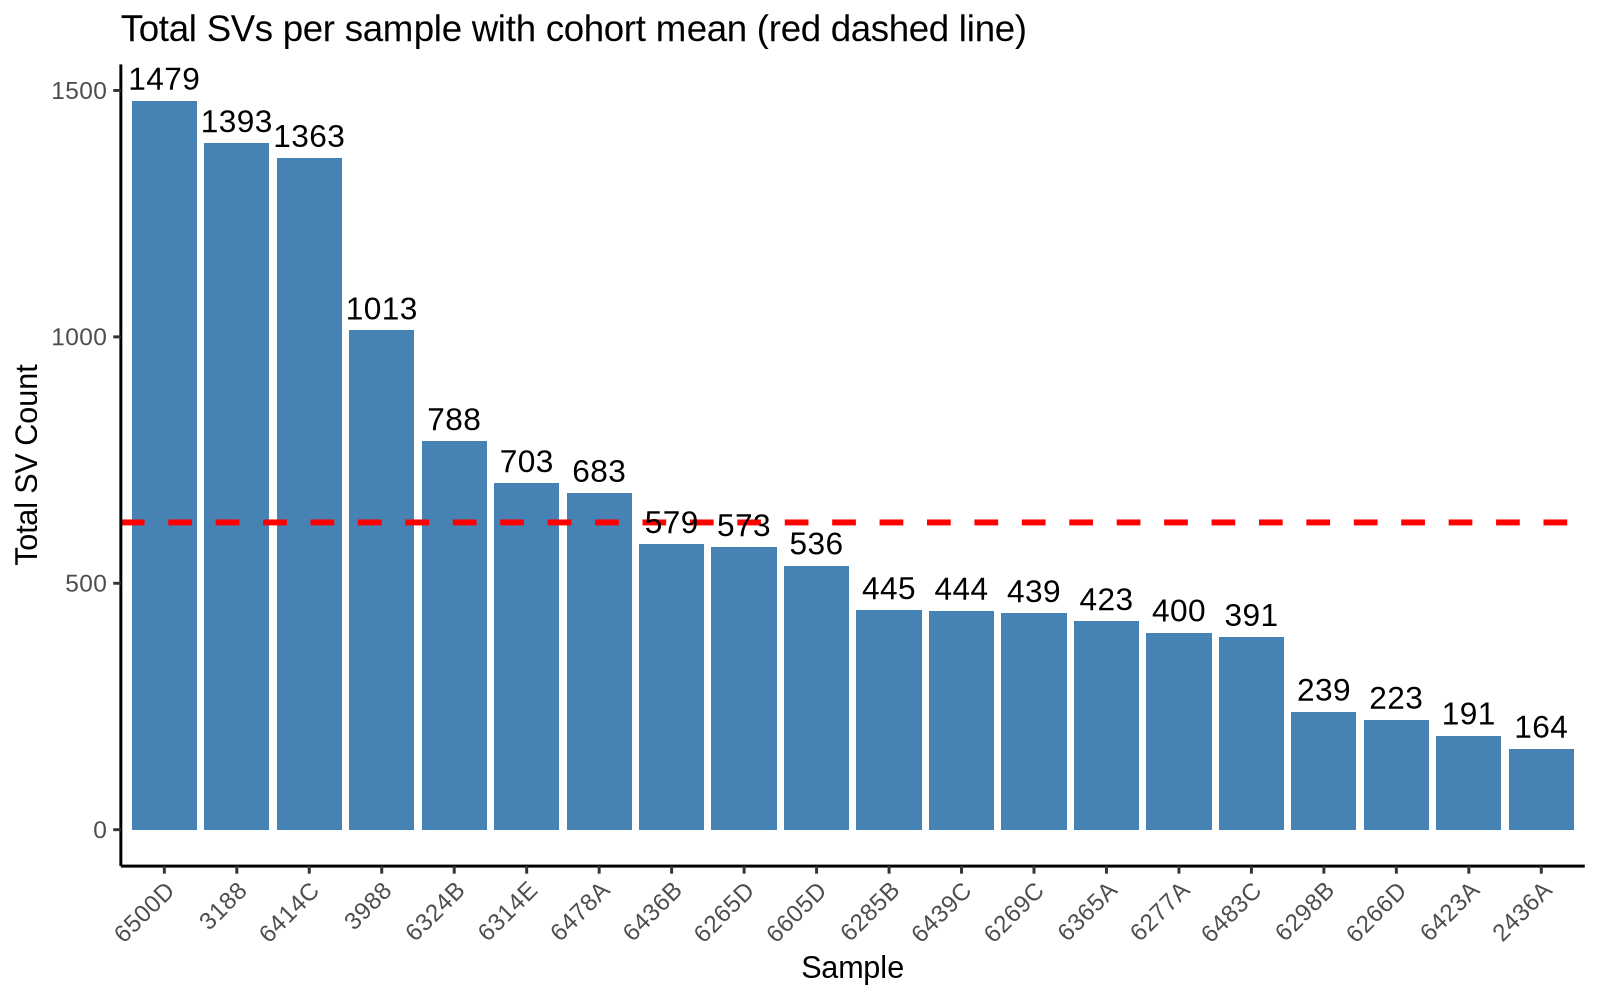

In [8]:
library(dplyr)
library(ggplot2)

# Count total SVs per sample
sv_counts_sample <- data %>%
  group_by(filename) %>%
  summarize(total_SVs = n(), .groups = "drop")

# Calculate cohort mean
mean_SVs <- mean(sv_counts_sample$total_SVs)
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 200)

# Plot total SVs per sample with cohort mean line
p<- ggplot(sv_counts_sample, aes(x = reorder(filename, -total_SVs), y = total_SVs)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  geom_hline(yintercept = mean_SVs, linetype = "dashed", color = "red", size = 1) +
  geom_text(aes(label = total_SVs), vjust = -0.5, size = 4) +  # show counts
  labs(x = "Sample", y = "Total SV Count",
       title = "Total SVs per sample with cohort mean (red dashed line)") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
p

In [9]:
outdir <- "/home/mjehangir/telomere-sv-analysis/plots/fig2/severus/"
dir.create(outdir, showWarnings = FALSE, recursive = TRUE)
ggsave(file.path(outdir, "severus_total_SV_counts_per_patient.pdf"), plot = p, width = 7, height = 5, dpi = 200)
#ggsave(file.path(outdir, "severus_total_SV_counts_per_sv_type.pdf"), plot = r, width = 7, height = 5, dpi = 200)


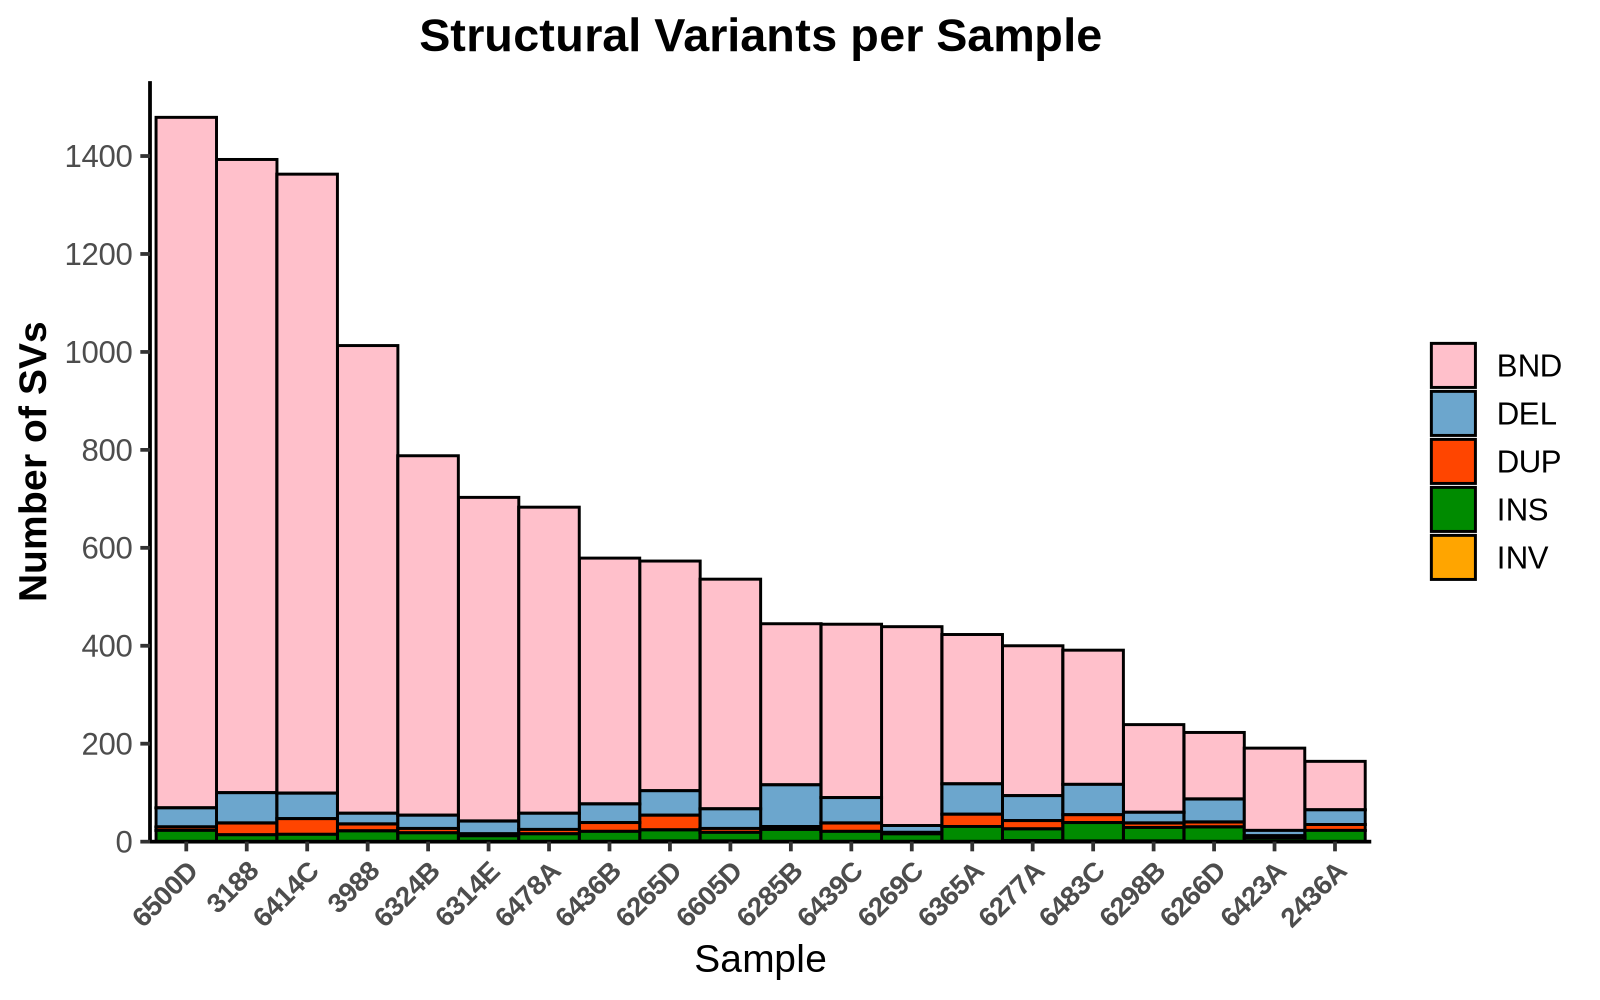

In [11]:
library(ggplot2)
library(dplyr)
library(forcats)
library(scales)


# Custom colors
sv_colors <- c("DEL" = "skyblue3",
               "DUP" = "orangered",
               "BND" = "pink",
               "INV" = "orange",
              "INS" = "green4")

#–––––––––––––––––––––––––––––––––––––
# p1: SV counts per sample (sorted & stacked)
#–––––––––––––––––––––––––––––––––––––
# Order samples by total SV counts
sample_order <- data %>%
  count(filename) %>%
  arrange(desc(n)) %>%
  pull(filename)

p1 <- data %>%
  count(filename, type) %>%
  mutate(filename = factor(filename, levels = sample_order)) %>%
  ggplot(aes(x = filename, y = n, fill = type)) +
  geom_bar(stat = "identity", position = "stack", color = "black", width = 1) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.05)), 
                     breaks = pretty_breaks(n = 6)) +
  scale_fill_manual(values = sv_colors) +
  labs(x = "Sample", y = "Number of SVs",
       title = "Structural Variants per Sample") +
  theme_classic(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, face = "bold", size = 10),
    axis.title.y = element_text(face = "bold"),
    plot.title  = element_text(face = "bold", hjust = 0.5),
    legend.title = element_blank()
  )

#–––––––––––––––––––––––––––––––––––––
# p2: Size distribution separate for each type
#–––––––––––––––––––––––––––––––––––––
# Define size bins
#data_bins <- data_noINS %>%
 # mutate(size_bin = cut(size,
  #                      breaks = c(0, 1e3, 1e4, 1e5, 1e6, Inf),
   #                     labels = c("<1 kb", "1–10 kb", "10–100 kb", "100 kb–1 Mb", ">1 Mb"),
    #                    right = FALSE))


data_bins <- data %>%
  mutate(
    size_bin = cut(
      size,
      breaks = c(0, 1e2, 5e2, 1e3, 5e3, 1e4, 1e5, 1e6, 1e7, Inf),
      labels = c("<0.1 kb", "0.1–0.5 kb", "0.5–1 kb", "1–5 kb", "5–10 kb",
                 "10–100 kb", "0.1–1 Mb", "1–10 Mb", ">10 Mb"),
      right = FALSE,
      include.lowest = TRUE
    )
  )
p1


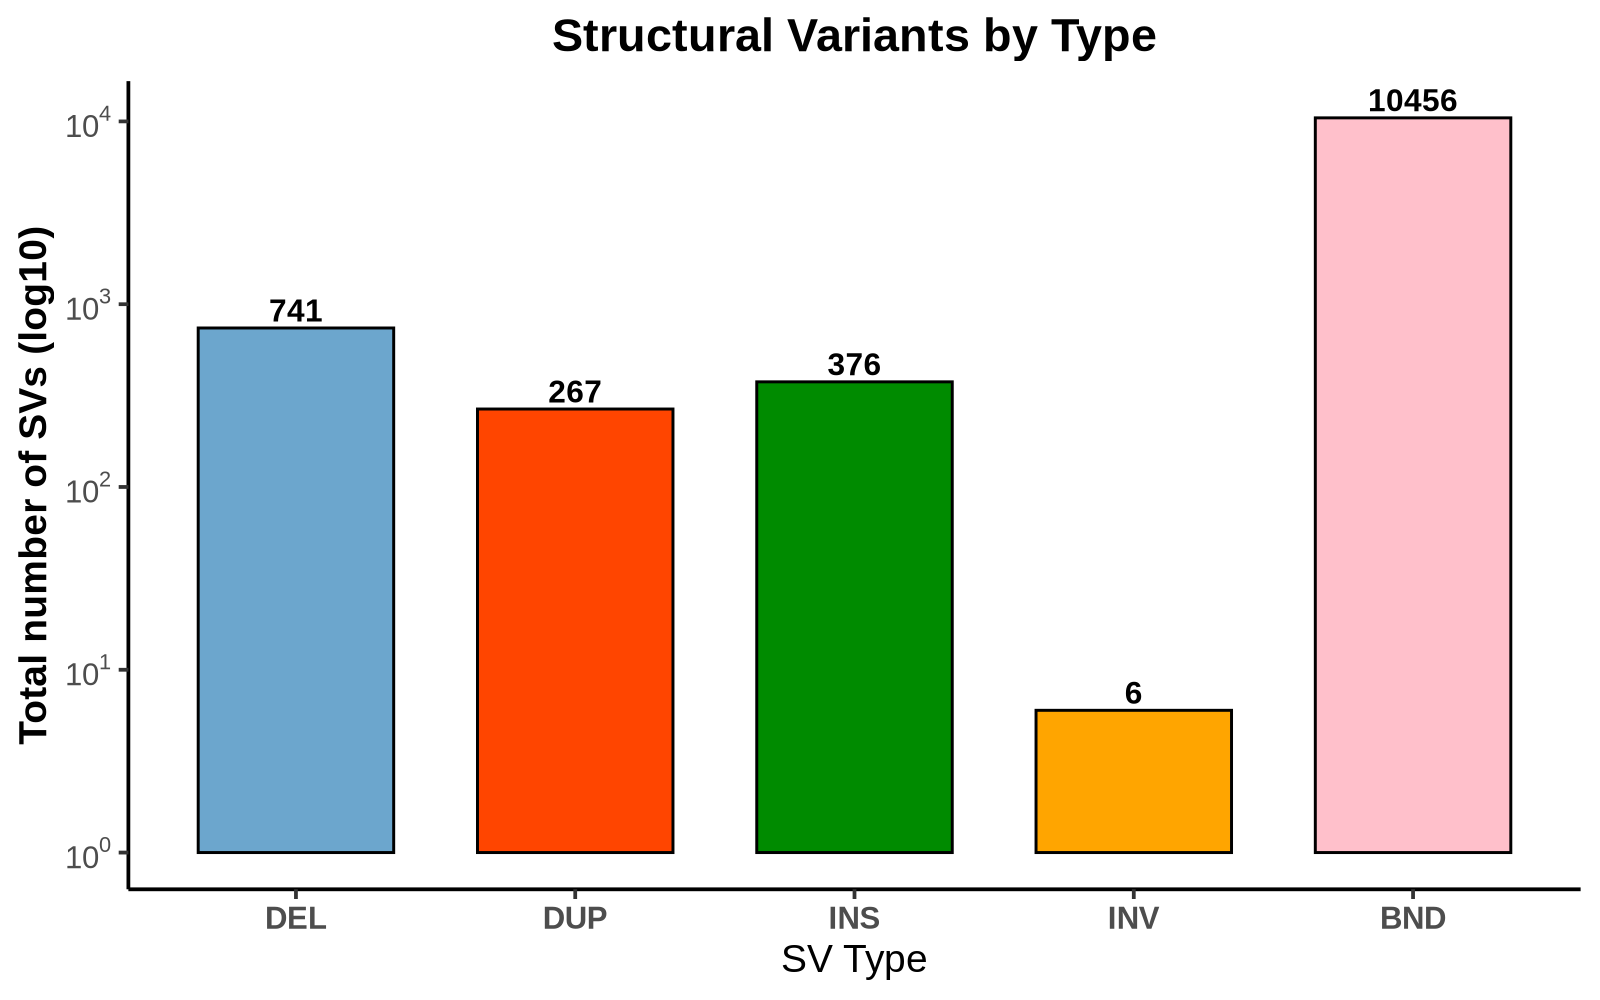

In [23]:
# Load libraries
library(ggplot2)
library(dplyr)
library(scales)

# -------------------------------
# 1. Enforce SV type order
data$type <- factor(
  data$type,
  levels = c("DEL", "DUP", "INS", "INV", "BND")
)

# -------------------------------
# 2. Define custom colors
sv_colors <- c(
  "DEL" = "skyblue3",
  "DUP" = "orangered",
  "BND" = "pink",
  "INV" = "orange",
  "INS" = "green4"
)

# -------------------------------
# 3. Summarize data
sv_summary <- data %>%
  count(type)
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 200)

# -------------------------------
# 4. Plot: bars per SV type with log10 y-axis
p_type_log <- ggplot(sv_summary, aes(x = type, y = n, fill = type)) +
  geom_bar(stat = "identity", color = "black", width = 0.7) +
  scale_fill_manual(values = sv_colors, guide = "none") +
  scale_y_log10(
    breaks = scales::trans_breaks("log10", function(x) 10^x),
    labels = scales::trans_format("log10", scales::math_format(10^.x))
  ) +
  geom_text(
    aes(label = n),
    vjust = -0.3,
    size = 4,
    fontface = "bold"
  ) +
  labs(
    x = "SV Type",
    y = "Total number of SVs (log10)",
    title = "Structural Variants by Type"
  ) +
  theme_classic(base_size = 14) +
  theme(
    axis.text.x = element_text(face = "bold"),
    axis.title.y = element_text(face = "bold"),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

# -------------------------------
# 5. Show plot
p_type_log


In [24]:
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig2/severus/supply_SV_by_type_log.pdf",   # output filename
  plot = p_type_log,                 # the plot object
  width = 6,                         # width in inches
  height = 5,                        # height in inches
  units = "in",
  dpi = 300
)

In [25]:
head(data_bins)

,chr,start,end,size,type,filename,size_bin
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<fct>
1,chr1,3010201,3010201,0,INS,2436A,<0.1 kb
2,chr1,8976617,8976617,0,INS,2436A,<0.1 kb
3,chr1,15789450,15789450,0,INS,2436A,<0.1 kb
4,chr1,39784669,39800629,15960,DUP,2436A,10–100 kb
5,chr1,39784669,39784669,0,BND,2436A,<0.1 kb
6,chr1,39784746,39800822,16076,DUP,2436A,10–100 kb


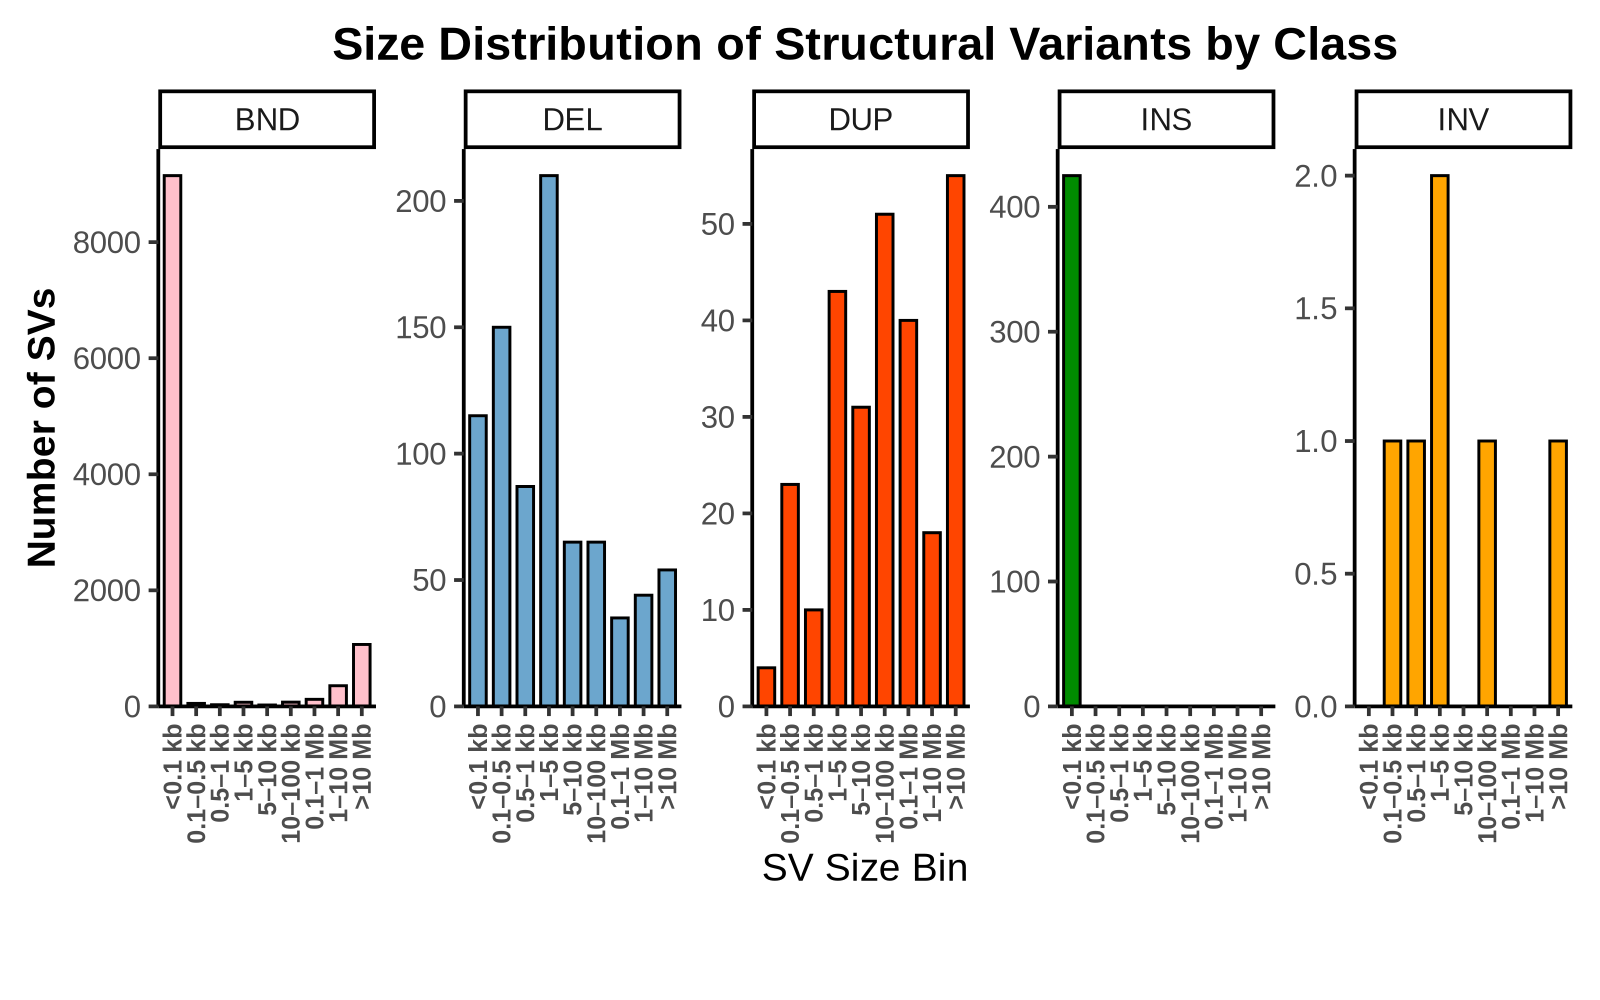

In [13]:
p2 <- data_bins %>%
  count(size_bin, type) %>%
  ggplot(aes(x = size_bin, y = n, fill = type)) +
  geom_bar(stat = "identity", color = "black", width = 0.7) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.05)),
                     breaks = scales::pretty_breaks(n = 6)) +
  scale_fill_manual(values = sv_colors) +
  facet_wrap(~ type, scales = "free_y", nrow = 1) +  # <- one row
  labs(x = "SV Size Bin", y = "Number of SVs",
       title = "Size Distribution of Structural Variants by Class") +
  theme_classic(base_size = 14) +
  theme(
    axis.text.x  = element_text(angle = 90, vjust = 0.5, hjust = 1, face = "bold", size = 9),
    axis.title.y = element_text(face = "bold"),
    plot.title   = element_text(face = "bold", hjust = 0.5),
    legend.position = "none",
    plot.margin = margin(t = 10, r = 10, b = 40, l = 10)
  )
p2

In [14]:
# Output directory
outdir <- "/home/mjehangir/telomere-sv-analysis/plots/fig2/severus/"
dir.create(outdir, showWarnings = FALSE, recursive = TRUE)
ggsave(file.path(outdir, "total_SV_count_v2.pdf"), plot = p1, width = 7, height = 5, dpi = 200)
ggsave(file.path(outdir, "size_distribution_v2.pdf"), plot = p2, width = 12, height = 4, dpi = 200)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '0.1–0.5 kb' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '0.5–1 kb' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '1–5 kb' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '5–10 kb' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '10–100 kb' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '0.1–1 Mb' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '1–10 Mb' in 'mbcsToSb

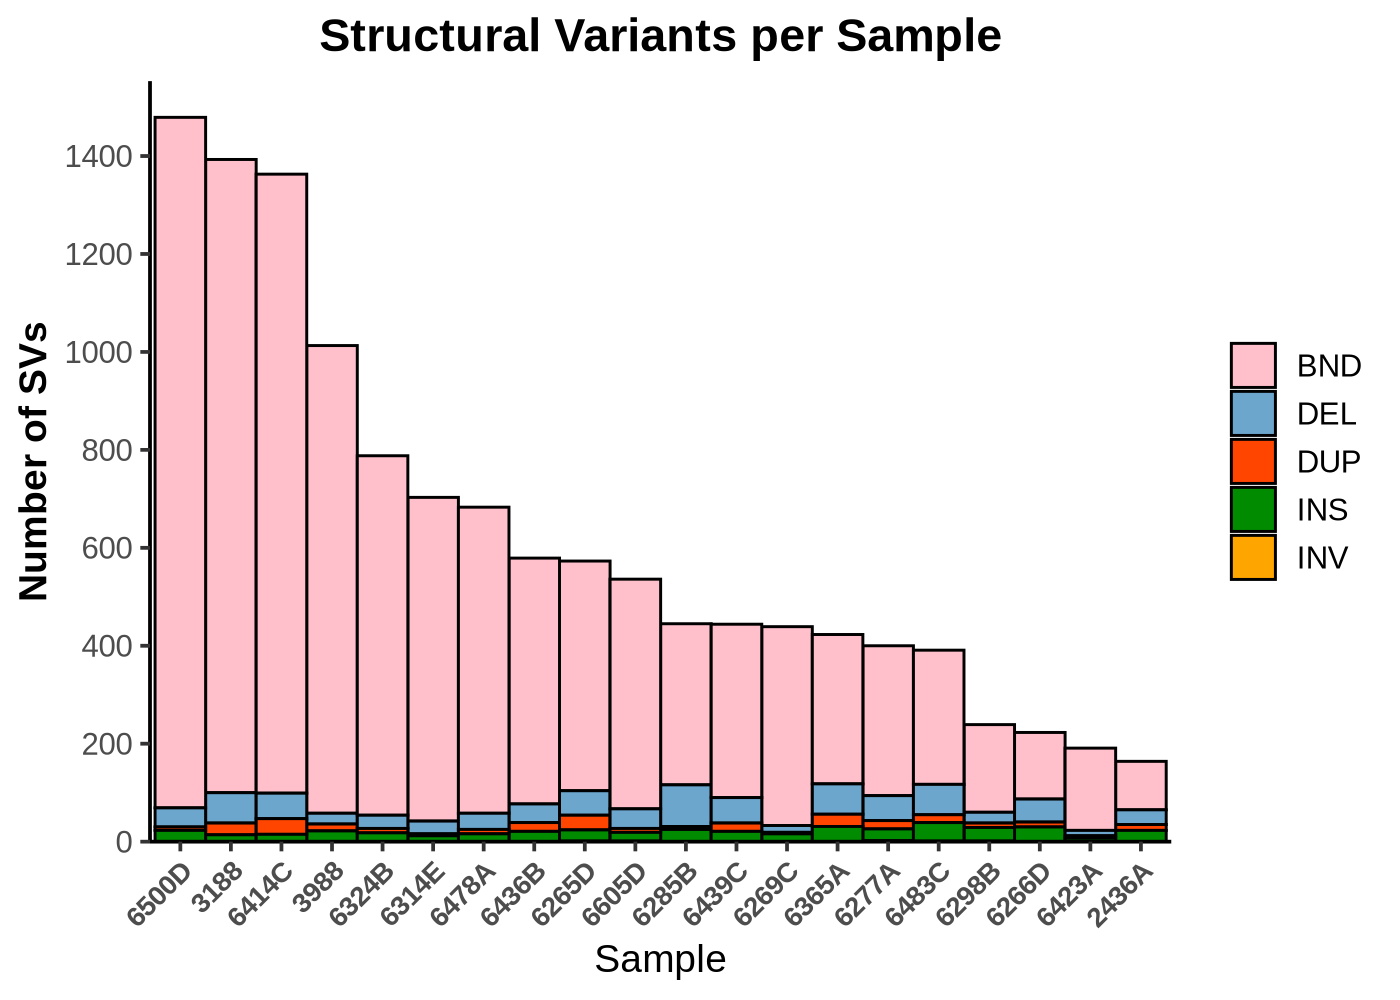

In [15]:
options(repr.plot.width = 7, repr.plot.height = 5, repr.plot.res = 200)

# Show plots
print(p1)

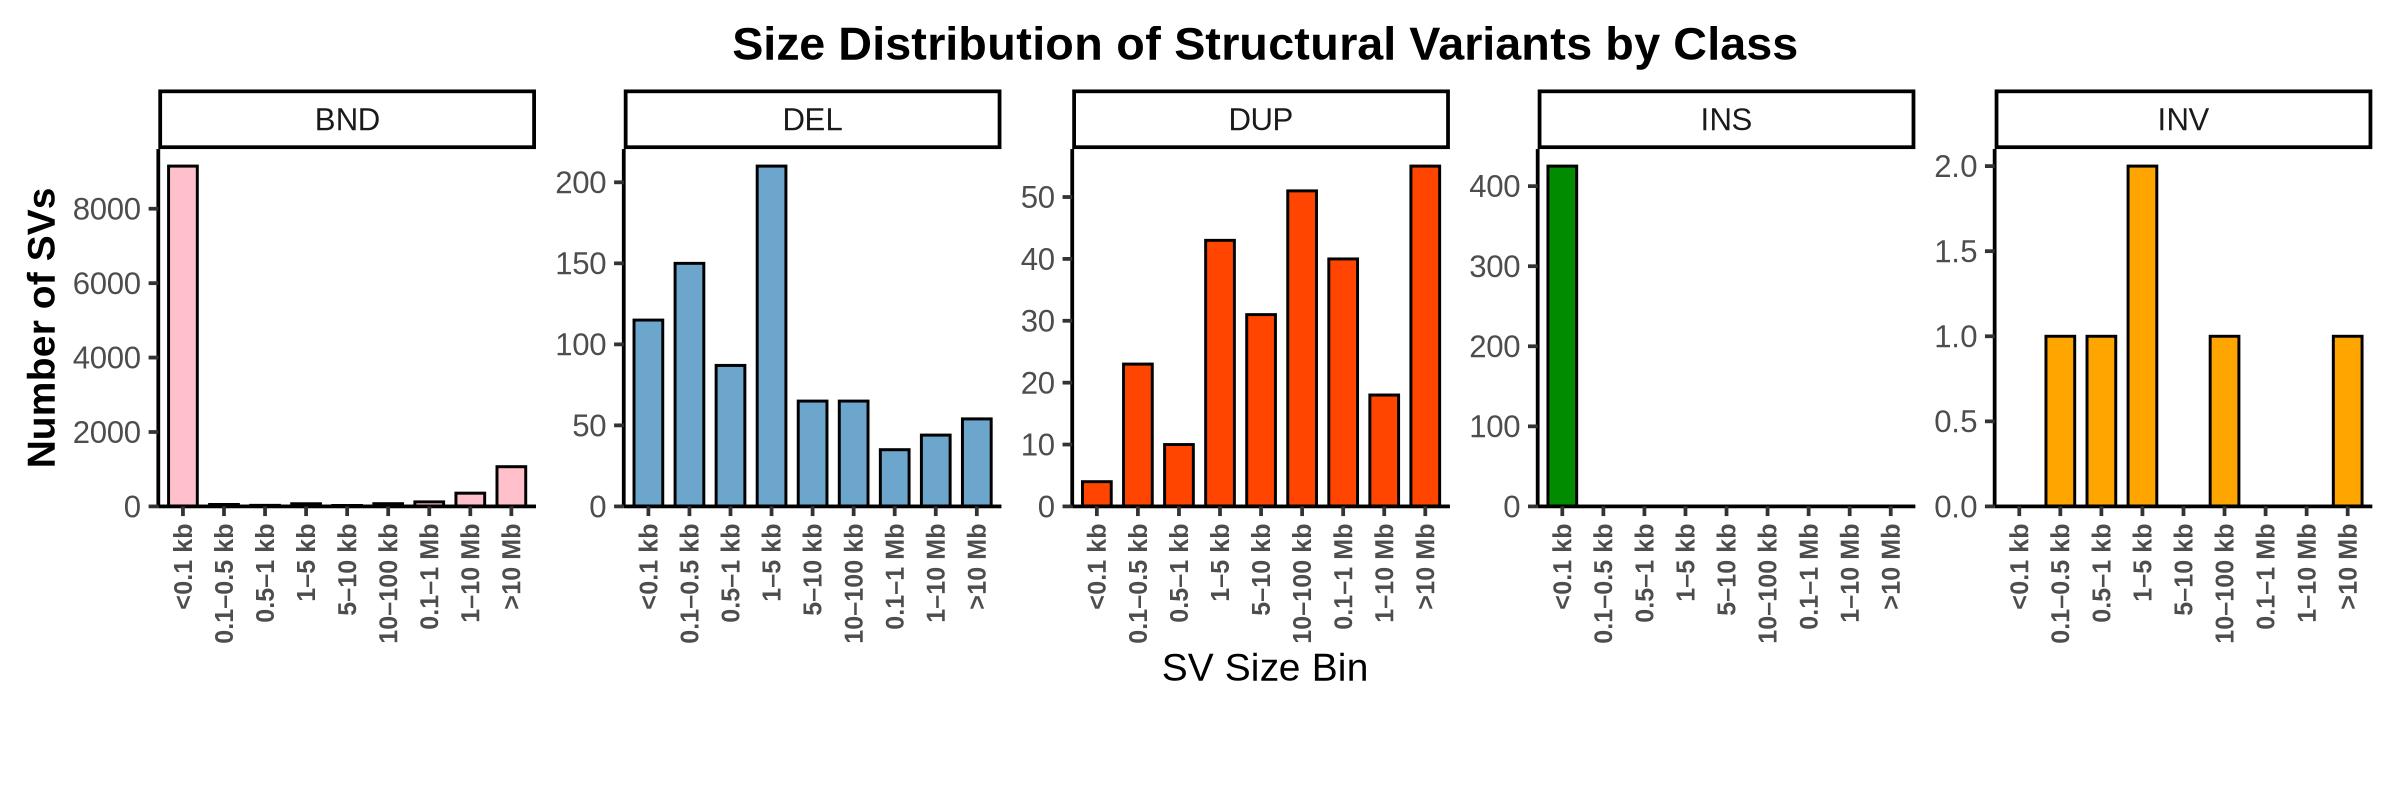

In [16]:
options(repr.plot.width = 12, repr.plot.height = 4, repr.plot.res = 200)

print(p2)

`summarise()` has grouped output by 'filename'. You can override using the
`.groups` argument.


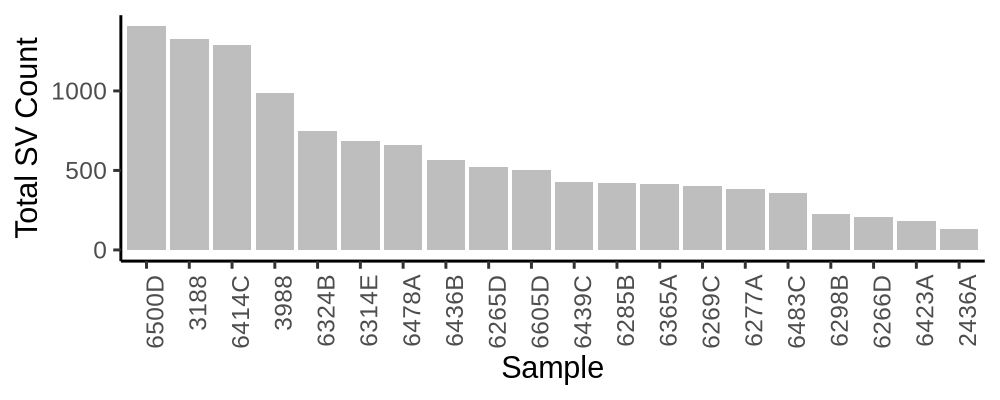

`summarise()` has grouped output by 'filename'. You can override using the
`.groups` argument.


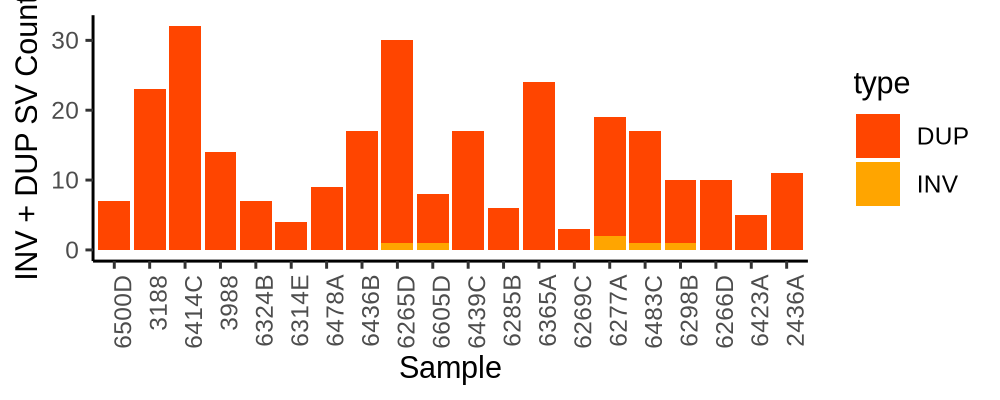

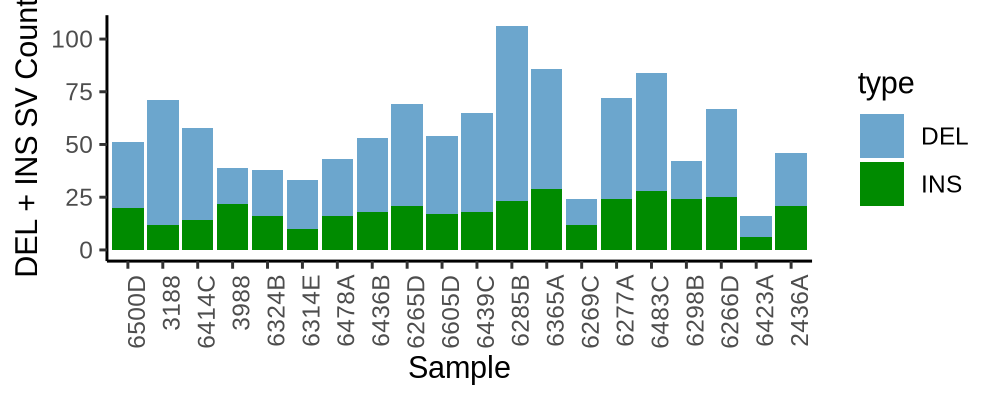

In [17]:

# Step 1: Filter the data to keep only chromosomes from chr1 to chr22
data <- data %>%
  filter(chr %in% paste0("chr", 1:22))  # Filter out chrX, chrY, chrM

# Step 2: Total SVs per sample bar plot (raw count, ordered descending)
total_SVs <- data %>%
  group_by(filename) %>%
  summarize(Total_SV = n())  # Count number of SVs per sample

# Sort samples by total SV count (descending order)
sorted_samples <- total_SVs %>%
  arrange(desc(Total_SV)) %>%
  pull(filename)

options(repr.plot.width = 5, repr.plot.height = 2, repr.plot.res = 200)

# Barplot for total SV count per sample (ordered descending)
ggplot(total_SVs, aes(x = factor(filename, levels = sorted_samples), y = Total_SV)) +
  geom_bar(stat = "identity", fill = "grey") +
  labs(x = "Sample", y = "Total SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))  # Rotate x-axis labels for clarity


# Step 3: Stacked bar plot by SV types (combining INV + DUP and DEL + INS into separate plots)
# INV + DUP combined Plot
sv_types_INV_DUP <- data %>%
  filter(type %in% c("INV", "DUP")) %>%
  group_by(filename, type) %>%
  summarize(SV_count_type = n())  # Count number of INV and DUP SVs per sample

ggplot(sv_types_INV_DUP, aes(x = factor(filename, levels = sorted_samples), y = SV_count_type, fill = type)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("INV" = "orange", "DUP" = "orangered")) +
  labs(x = "Sample", y = "INV + DUP SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))  # Rotate x-axis labels for clarity


# DEL + INS combined Plot
sv_types_DEL_INS <- data %>%
  filter(type %in% c("DEL", "INS")) %>%
  group_by(filename, type) %>%
  summarize(SV_count_type = n())  # Count number of DEL and INS SVs per sample

ggplot(sv_types_DEL_INS, aes(x = factor(filename, levels = sorted_samples), y = SV_count_type, fill = type)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("DEL" = "skyblue3", "INS" = "green4")) +
  labs(x = "Sample", y = "DEL + INS SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))  # Rotate x-axis labels for clarity